# AI Exposure Scores: Exploratory Data Analysis

This notebook analyzes three complementary measures of AI's impact on occupations:

1. **Task Exposure** - Direct LLM capability to perform occupation tasks (0-2 scale)
2. **Presence/Humanness** - Physical, emotional, and creative human requirements
3. **Felten Scores** - AI application relevance to occupation abilities

Together, these capture different dimensions of AI vulnerability:
- Task exposure measures *what AI can do*
- Humanness measures *what requires human presence*
- Felten scores measure *cognitive ability exposure*

In [ ]:
#|hide
import nblite; from nbdev.showdoc import show_doc; nblite.nbl_export()

In [ ]:
import aisi_economy_index as proj
from aisi_economy_index import const

In [ ]:
from dotenv import load_dotenv

load_dotenv() 

In [ ]:
from pathlib import Path

In [ ]:
BASE_DIR = Path("/Users/bhargav/adu_dev/aisi-economy-index/aisi_economy_index/store/data/db_30_0_excel")
OUT_DIR = Path(str(const.data_path)) / "eval_dfs"
OUT_DIR.mkdir(exist_ok=True)

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from mpl_toolkits.mplot3d import Axes3D

# Style settings
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11

%matplotlib inline

## 1. Loading and Merging Data

In [ ]:
# Load the three score datasets
task_df = pd.read_csv('SOC_codes/task_exposure_by_soc.csv')
presence_df = pd.read_csv('SOC_codes/presence_scores_by_soc.csv')
felten_df = pd.read_csv('SOC_codes/felten_scores_by_soc.csv')

print(f"Task exposure: {len(task_df)} occupations")
print(f"Presence scores: {len(presence_df)} occupations")
print(f"Felten scores: {len(felten_df)} occupations")

Task exposure: 923 occupations
Presence scores: 894 occupations
Felten scores: 894 occupations


In [ ]:
# Standardize SOC code column names for merging
felten_df = felten_df.rename(columns={'soc_code': 'OnetSocCode', 'title': 'Title_felten'})

# Merge all three datasets
merged = task_df.merge(
    presence_df, 
    on='OnetSocCode', 
    how='inner',
    suffixes=('', '_presence')
)

merged = merged.merge(
    felten_df,
    on='OnetSocCode',
    how='inner'
)

print(f"Merged dataset: {len(merged)} occupations with all three scores")
merged.head()

Merged dataset: 894 occupations with all three scores


,OnetSocCode,Title,n_tasks,mean_exposure,pct_level_0,pct_level_1,pct_level_2,exposure_freq_weighted,exposure_importance_weighted,mean_confidence,...,physical_imp_only,emotional_imp_lvl,emotional_imp_only,creative_imp_lvl,creative_imp_only,felten_original,baseline_2025,conservative_2025,genai_only,Title_felten
0,43-9021.00,Data Entry Keyers,11,1.545455,9.090909,27.272727,63.636364,1.605755,1.582776,0.802727,...,0.367417,0.429173,0.448104,0.550675,0.565556,0.585762,0.585185,0.583041,0.549104,Data Entry Keyers
1,43-9041.00,Insurance Claims and Policy Processing Clerks,28,1.321429,0.000000,67.857143,32.142857,1.270767,1.261439,0.830357,...,0.339917,0.437068,0.468125,0.472460,0.488889,0.607673,0.607137,0.606134,0.574545,Insurance Claims and Policy Processing Clerks
2,43-4151.00,Order Clerks,22,1.318182,4.545455,59.090909,36.363636,1.313329,1.318031,0.842273,...,0.418389,0.506010,0.549056,0.542202,0.577500,0.611009,0.610512,0.609289,0.577673,Order Clerks
3,13-2082.00,Tax Preparers,13,1.307692,0.000000,69.230769,30.769231,1.305738,1.300725,0.864615,...,0.323361,0.465732,0.473646,0.522579,0.525556,0.621517,0.621214,0.620630,0.590544,Tax Preparers
4,43-3031.00,"Bookkeeping, Accounting, and Auditing Clerks",32,1.281250,9.375000,53.125000,37.500000,1.272185,1.269713,0.863125,...,0.348639,0.421901,0.436160,0.490972,0.498889,0.611441,0.610930,0.609801,0.578571,"Bookkeeping, Accounting, and Auditing Clerks"


In [ ]:
# Create simplified score columns for analysis
# Normalize task exposure to 0-1 scale for comparability
merged['task_exposure_norm'] = merged['mean_exposure'] / 2.0

# Average humanness score (physical + emotional + creative)
merged['humanness_avg'] = (
    merged['physical_imp_lvl'] + 
    merged['emotional_imp_lvl'] + 
    merged['creative_imp_lvl']
) / 3

# Use baseline_2025 as primary Felten score
merged['felten_score'] = merged['baseline_2025']

# Create a composite vulnerability score
# High task exposure + high Felten + LOW humanness = high vulnerability
merged['vulnerability'] = (
    merged['task_exposure_norm'] + 
    merged['felten_score'] - 
    merged['humanness_avg']
) / 2  # Scale to roughly 0-1

print("Key score distributions:")
merged[['task_exposure_norm', 'humanness_avg', 'felten_score', 'vulnerability']].describe()

Key score distributions:


,task_exposure_norm,humanness_avg,felten_score,vulnerability
count,894.000000,894.000000,894.000000,894.000000
mean,0.292321,0.522270,0.582658,0.176355
std,0.177097,0.063184,0.030150,0.096280
min,0.000000,0.330055,0.516453,-0.021826
25%,0.119048,0.481315,0.555670,0.094658
50%,0.312500,0.526791,0.579050,0.173329
75%,0.458333,0.567544,0.612260,0.259155
max,0.772727,0.682365,0.634377,0.458084


## 2. Score Distributions

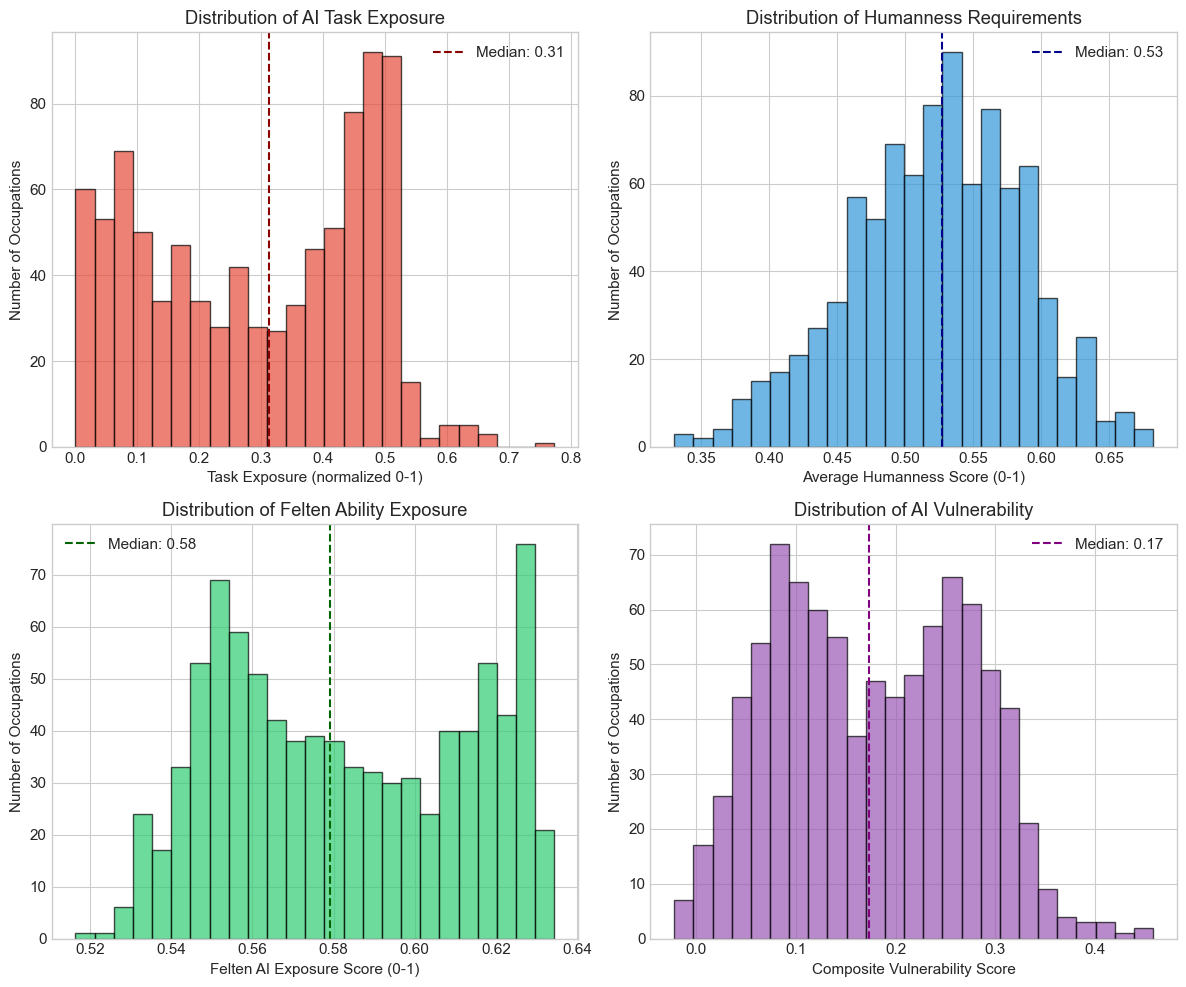

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Task Exposure
axes[0, 0].hist(merged['task_exposure_norm'], bins=25, edgecolor='black', alpha=0.7, color='#e74c3c')
axes[0, 0].set_xlabel('Task Exposure (normalized 0-1)')
axes[0, 0].set_ylabel('Number of Occupations')
axes[0, 0].set_title('Distribution of AI Task Exposure')
axes[0, 0].axvline(merged['task_exposure_norm'].median(), color='darkred', linestyle='--', label=f'Median: {merged["task_exposure_norm"].median():.2f}')
axes[0, 0].legend()

# Humanness
axes[0, 1].hist(merged['humanness_avg'], bins=25, edgecolor='black', alpha=0.7, color='#3498db')
axes[0, 1].set_xlabel('Average Humanness Score (0-1)')
axes[0, 1].set_ylabel('Number of Occupations')
axes[0, 1].set_title('Distribution of Humanness Requirements')
axes[0, 1].axvline(merged['humanness_avg'].median(), color='darkblue', linestyle='--', label=f'Median: {merged["humanness_avg"].median():.2f}')
axes[0, 1].legend()

# Felten
axes[1, 0].hist(merged['felten_score'], bins=25, edgecolor='black', alpha=0.7, color='#2ecc71')
axes[1, 0].set_xlabel('Felten AI Exposure Score (0-1)')
axes[1, 0].set_ylabel('Number of Occupations')
axes[1, 0].set_title('Distribution of Felten Ability Exposure')
axes[1, 0].axvline(merged['felten_score'].median(), color='darkgreen', linestyle='--', label=f'Median: {merged["felten_score"].median():.2f}')
axes[1, 0].legend()

# Composite Vulnerability
axes[1, 1].hist(merged['vulnerability'], bins=25, edgecolor='black', alpha=0.7, color='#9b59b6')
axes[1, 1].set_xlabel('Composite Vulnerability Score')
axes[1, 1].set_ylabel('Number of Occupations')
axes[1, 1].set_title('Distribution of AI Vulnerability')
axes[1, 1].axvline(merged['vulnerability'].median(), color='purple', linestyle='--', label=f'Median: {merged["vulnerability"].median():.2f}')
axes[1, 1].legend()

plt.tight_layout()
plt.savefig('SOC_codes/score_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Correlation Analysis: How Complementary Are the Scores?

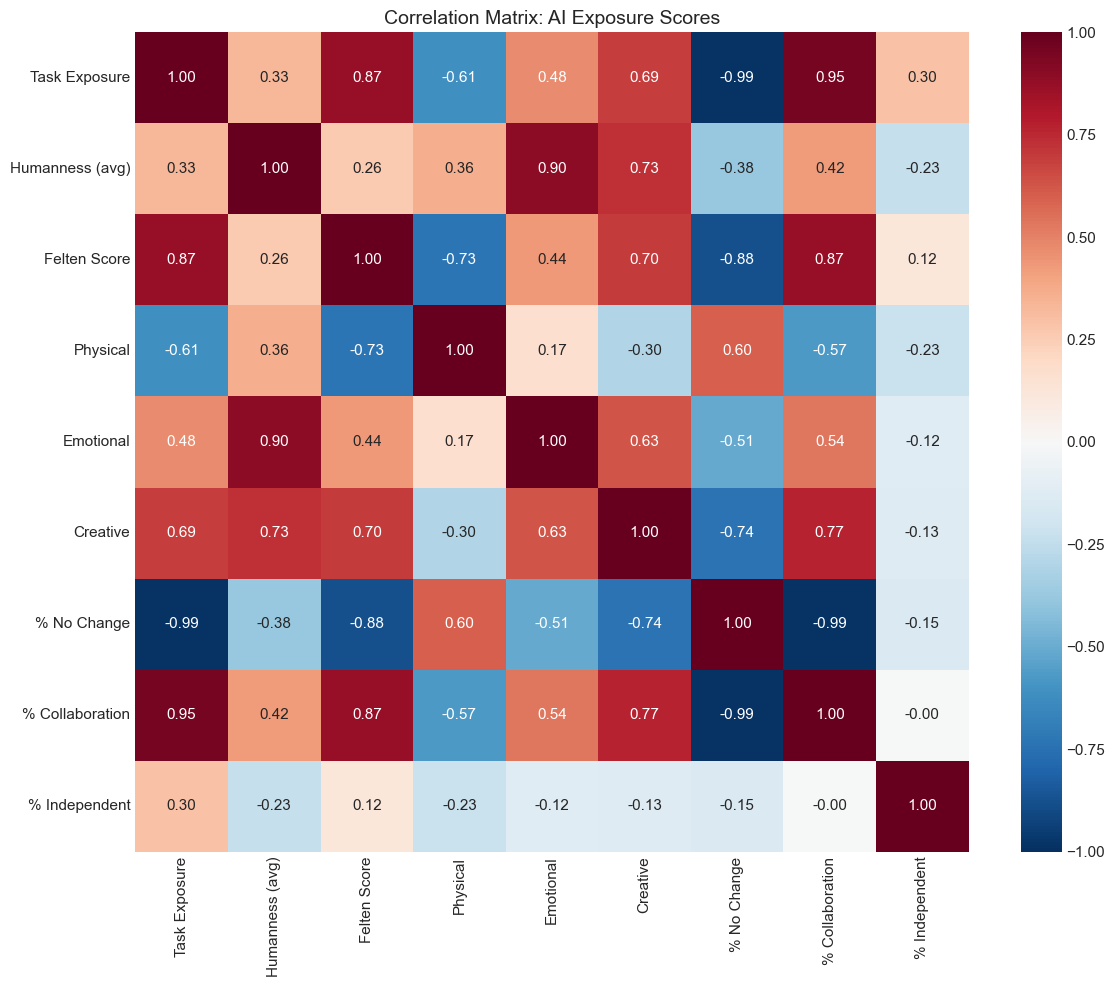


Key Correlations:
Task Exposure vs Humanness: r = 0.334
Task Exposure vs Felten: r = 0.870
Humanness vs Felten: r = 0.262


In [ ]:
# Compute correlation matrix for key scores
score_cols = [
    'task_exposure_norm', 'humanness_avg', 'felten_score',
    'physical_imp_lvl', 'emotional_imp_lvl', 'creative_imp_lvl',
    'pct_level_0', 'pct_level_1', 'pct_level_2'
]

corr_matrix = merged[score_cols].corr()

# Rename for cleaner display
labels = [
    'Task Exposure', 'Humanness (avg)', 'Felten Score',
    'Physical', 'Emotional', 'Creative',
    '% No Change', '% Collaboration', '% Independent'
]

plt.figure(figsize=(12, 10))
sns.heatmap(
    corr_matrix, 
    annot=True, 
    fmt='.2f', 
    cmap='RdBu_r',
    center=0,
    xticklabels=labels,
    yticklabels=labels,
    vmin=-1, vmax=1
)
plt.title('Correlation Matrix: AI Exposure Scores', fontsize=14)
plt.tight_layout()
plt.savefig('SOC_codes/correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

# Key correlations
print("\nKey Correlations:")
print(f"Task Exposure vs Humanness: r = {corr_matrix.loc['task_exposure_norm', 'humanness_avg']:.3f}")
print(f"Task Exposure vs Felten: r = {corr_matrix.loc['task_exposure_norm', 'felten_score']:.3f}")
print(f"Humanness vs Felten: r = {corr_matrix.loc['humanness_avg', 'felten_score']:.3f}")

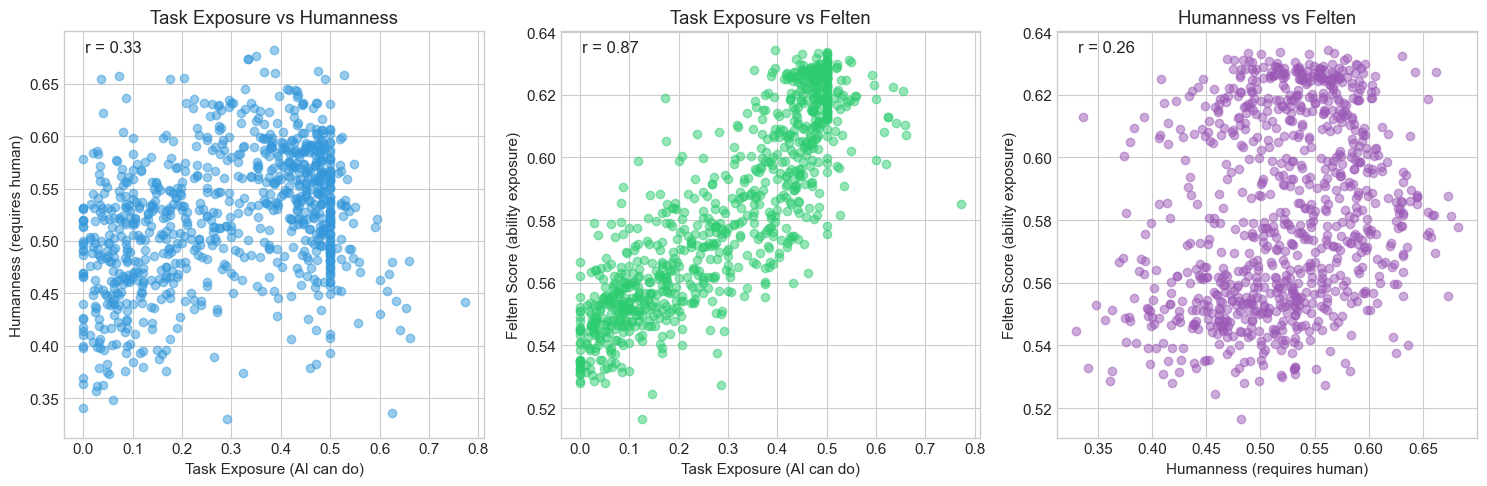

In [ ]:
# Pairwise scatter plots to show complementarity
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Task vs Humanness
axes[0].scatter(merged['task_exposure_norm'], merged['humanness_avg'], alpha=0.5, c='#3498db')
axes[0].set_xlabel('Task Exposure (AI can do)')
axes[0].set_ylabel('Humanness (requires human)')
axes[0].set_title('Task Exposure vs Humanness')
r1 = merged['task_exposure_norm'].corr(merged['humanness_avg'])
axes[0].annotate(f'r = {r1:.2f}', xy=(0.05, 0.95), xycoords='axes fraction', fontsize=12)

# Task vs Felten
axes[1].scatter(merged['task_exposure_norm'], merged['felten_score'], alpha=0.5, c='#2ecc71')
axes[1].set_xlabel('Task Exposure (AI can do)')
axes[1].set_ylabel('Felten Score (ability exposure)')
axes[1].set_title('Task Exposure vs Felten')
r2 = merged['task_exposure_norm'].corr(merged['felten_score'])
axes[1].annotate(f'r = {r2:.2f}', xy=(0.05, 0.95), xycoords='axes fraction', fontsize=12)

# Humanness vs Felten
axes[2].scatter(merged['humanness_avg'], merged['felten_score'], alpha=0.5, c='#9b59b6')
axes[2].set_xlabel('Humanness (requires human)')
axes[2].set_ylabel('Felten Score (ability exposure)')
axes[2].set_title('Humanness vs Felten')
r3 = merged['humanness_avg'].corr(merged['felten_score'])
axes[2].annotate(f'r = {r3:.2f}', xy=(0.05, 0.95), xycoords='axes fraction', fontsize=12)

plt.tight_layout()
plt.savefig('SOC_codes/pairwise_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

### Interpretation: Score Complementarity

The three scores capture different dimensions of AI impact:

- **Task Exposure** measures direct LLM capability on specific work tasks
- **Humanness** measures requirements for physical presence, emotional intelligence, and creativity
- **Felten Score** measures exposure based on underlying cognitive abilities

Low correlations indicate the scores are capturing distinct aspects of work, making them complementary rather than redundant.

## 4. Vulnerability Analysis: Most and Least Exposed Occupations

In [ ]:
# Sort by composite vulnerability
merged_sorted = merged.sort_values('vulnerability', ascending=False)

print("=" * 80)
print("TOP 20 MOST VULNERABLE OCCUPATIONS")
print("(High AI task exposure + High Felten + Low humanness requirements)")
print("=" * 80)

top_20 = merged_sorted.head(20)[['Title', 'task_exposure_norm', 'humanness_avg', 'felten_score', 'vulnerability']]
top_20.columns = ['Occupation', 'Task Exp.', 'Humanness', 'Felten', 'Vulnerability']
print(top_20.to_string(index=False))

TOP 20 MOST VULNERABLE OCCUPATIONS
(High AI task exposure + High Felten + Low humanness requirements)
                                      Occupation  Task Exp.  Humanness   Felten  Vulnerability
                               Data Entry Keyers   0.772727   0.441744 0.585185       0.458084
                   Proofreaders and Copy Markers   0.625000   0.336176 0.612897       0.450861
   Insurance Claims and Policy Processing Clerks   0.660714   0.407523 0.607137       0.430164
                                   Tax Preparers   0.653846   0.436407 0.621214       0.419327
    Bookkeeping, Accounting, and Auditing Clerks   0.640625   0.415091 0.610930       0.418232
                          Statistical Assistants   0.633333   0.442509 0.622539       0.406682
                                    Order Clerks   0.659091   0.481367 0.610512       0.394118
                                   Telemarketers   0.615385   0.451995 0.607995       0.385692
                     Word Processors and Ty

In [ ]:
print("\n" + "=" * 80)
print("TOP 20 LEAST VULNERABLE OCCUPATIONS")
print("(Low AI task exposure + Low Felten + High humanness requirements)")
print("=" * 80)

bottom_20 = merged_sorted.tail(20)[['Title', 'task_exposure_norm', 'humanness_avg', 'felten_score', 'vulnerability']]
bottom_20.columns = ['Occupation', 'Task Exp.', 'Humanness', 'Felten', 'Vulnerability']
print(bottom_20.to_string(index=False))


TOP 20 LEAST VULNERABLE OCCUPATIONS
(Low AI task exposure + Low Felten + High humanness requirements)
                                           Occupation  Task Exp.  Humanness   Felten  Vulnerability
                                  Helpers--Carpenters   0.000000   0.513069 0.540357       0.013644
                                Pile Driver Operators   0.000000   0.520057 0.545010       0.012476
       Electrical Power-Line Installers and Repairers   0.034483   0.556913 0.544792       0.011181
                    Structural Iron and Steel Workers   0.020833   0.531165 0.532440       0.011055
                             Roustabouts, Oil and Gas   0.000000   0.518783 0.538554       0.009885
                                Helpers--Electricians   0.014706   0.534988 0.540017       0.009867
                          Highway Maintenance Workers   0.019231   0.544703 0.544459       0.009493
Rail-Track Laying and Maintenance Equipment Operators   0.000000   0.530629 0.540924       0.0051

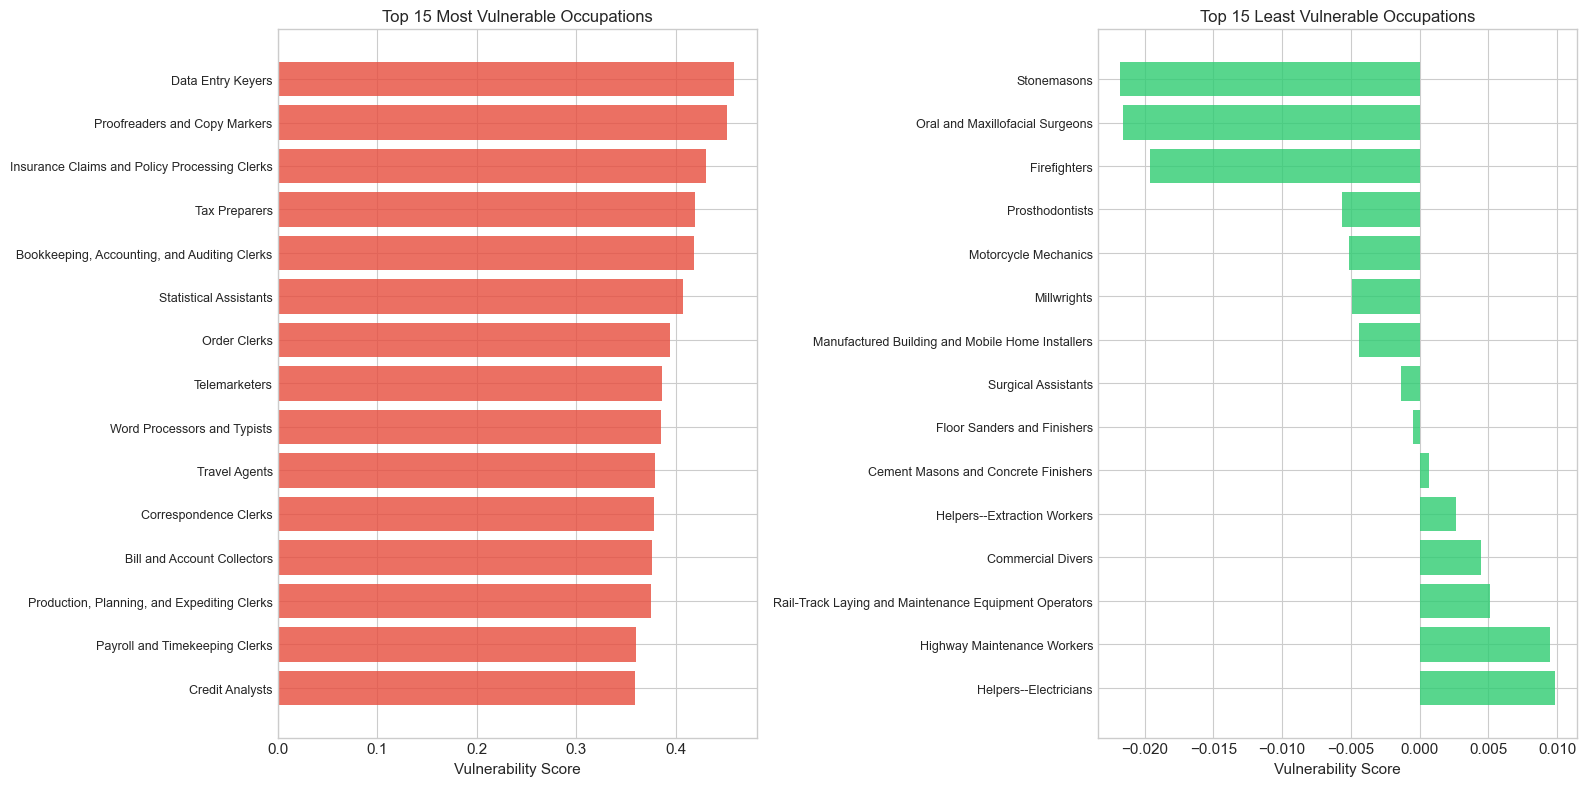

In [ ]:
# Visualize top and bottom occupations
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# Top 15 most vulnerable
top_15 = merged_sorted.head(15)
y_pos = range(len(top_15))
axes[0].barh(y_pos, top_15['vulnerability'], color='#e74c3c', alpha=0.8)
axes[0].set_yticks(y_pos)
axes[0].set_yticklabels(top_15['Title'], fontsize=9)
axes[0].invert_yaxis()
axes[0].set_xlabel('Vulnerability Score')
axes[0].set_title('Top 15 Most Vulnerable Occupations', fontsize=12)

# Bottom 15 least vulnerable
bottom_15 = merged_sorted.tail(15).iloc[::-1]
y_pos = range(len(bottom_15))
axes[1].barh(y_pos, bottom_15['vulnerability'], color='#2ecc71', alpha=0.8)
axes[1].set_yticks(y_pos)
axes[1].set_yticklabels(bottom_15['Title'], fontsize=9)
axes[1].invert_yaxis()
axes[1].set_xlabel('Vulnerability Score')
axes[1].set_title('Top 15 Least Vulnerable Occupations', fontsize=12)

plt.tight_layout()
plt.savefig('SOC_codes/vulnerability_extremes.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Quadrant Analysis: Mapping the AI-Human Work Landscape

In [ ]:
# Create quadrants based on Task Exposure vs Humanness
task_median = merged['task_exposure_norm'].median()
human_median = merged['humanness_avg'].median()

def assign_quadrant(row):
    if row['task_exposure_norm'] >= task_median and row['humanness_avg'] >= human_median:
        return 'High Exposure, High Humanness\n(Augmentation Zone)'
    elif row['task_exposure_norm'] >= task_median and row['humanness_avg'] < human_median:
        return 'High Exposure, Low Humanness\n(Automation Risk)'
    elif row['task_exposure_norm'] < task_median and row['humanness_avg'] >= human_median:
        return 'Low Exposure, High Humanness\n(Human Stronghold)'
    else:
        return 'Low Exposure, Low Humanness\n(Manual/Physical Work)'

merged['quadrant'] = merged.apply(assign_quadrant, axis=1)

# Count occupations in each quadrant
quadrant_counts = merged['quadrant'].value_counts()
print("Occupation Distribution by Quadrant:")
print(quadrant_counts)

Occupation Distribution by Quadrant:
quadrant
High Exposure, High Humanness\n(Augmentation Zone)     292
Low Exposure, Low Humanness\n(Manual/Physical Work)    290
High Exposure, Low Humanness\n(Automation Risk)        157
Low Exposure, High Humanness\n(Human Stronghold)       155
Name: count, dtype: int64


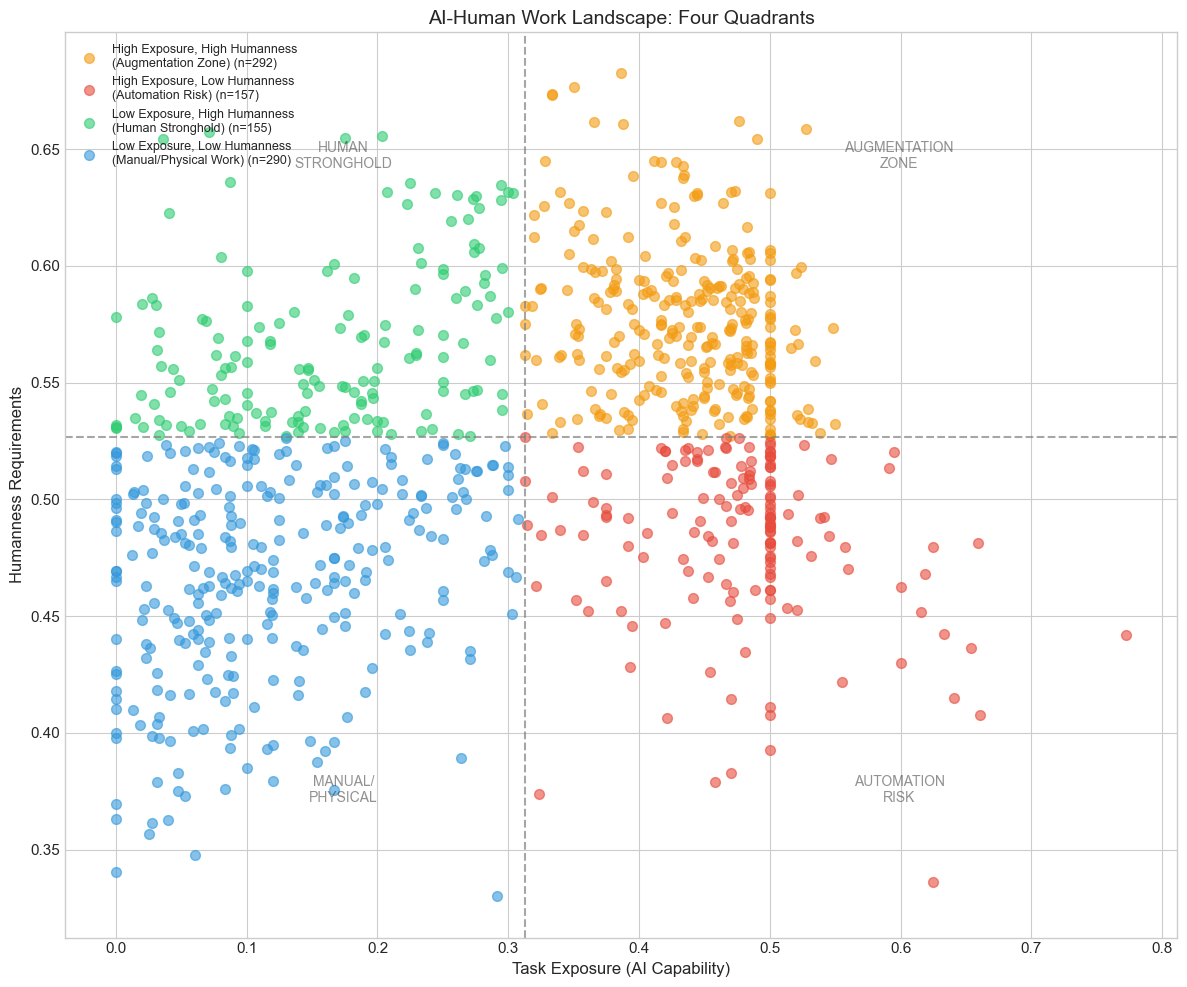

In [ ]:
# Quadrant scatter plot
fig, ax = plt.subplots(figsize=(12, 10))

colors = {
    'High Exposure, High Humanness\n(Augmentation Zone)': '#f39c12',
    'High Exposure, Low Humanness\n(Automation Risk)': '#e74c3c',
    'Low Exposure, High Humanness\n(Human Stronghold)': '#2ecc71',
    'Low Exposure, Low Humanness\n(Manual/Physical Work)': '#3498db'
}

for quadrant, color in colors.items():
    subset = merged[merged['quadrant'] == quadrant]
    ax.scatter(
        subset['task_exposure_norm'], 
        subset['humanness_avg'],
        c=color, 
        label=f"{quadrant} (n={len(subset)})",
        alpha=0.6,
        s=50
    )

# Add quadrant lines
ax.axvline(task_median, color='gray', linestyle='--', alpha=0.7)
ax.axhline(human_median, color='gray', linestyle='--', alpha=0.7)

# Labels
ax.set_xlabel('Task Exposure (AI Capability)', fontsize=12)
ax.set_ylabel('Humanness Requirements', fontsize=12)
ax.set_title('AI-Human Work Landscape: Four Quadrants', fontsize=14)
ax.legend(loc='upper left', fontsize=9)

# Add quadrant labels
ax.text(0.75, 0.85, 'AUGMENTATION\nZONE', transform=ax.transAxes, fontsize=10, ha='center', alpha=0.5)
ax.text(0.75, 0.15, 'AUTOMATION\nRISK', transform=ax.transAxes, fontsize=10, ha='center', alpha=0.5)
ax.text(0.25, 0.85, 'HUMAN\nSTRONGHOLD', transform=ax.transAxes, fontsize=10, ha='center', alpha=0.5)
ax.text(0.25, 0.15, 'MANUAL/\nPHYSICAL', transform=ax.transAxes, fontsize=10, ha='center', alpha=0.5)

plt.tight_layout()
plt.savefig('SOC_codes/quadrant_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# Show example occupations in each quadrant
print("\n" + "=" * 80)
print("EXAMPLE OCCUPATIONS BY QUADRANT")
print("=" * 80)

for quadrant in colors.keys():
    subset = merged[merged['quadrant'] == quadrant].sort_values('vulnerability', ascending=False)
    print(f"\n{quadrant}:")
    examples = subset.head(5)['Title'].tolist()
    for ex in examples:
        print(f"  • {ex}")


EXAMPLE OCCUPATIONS BY QUADRANT

High Exposure, High Humanness
(Augmentation Zone):
  • Survey Researchers
  • Dispatchers, Except Police, Fire, and Ambulance
  • Human Resources Specialists
  • Agents and Business Managers of Artists, Performers, and Athletes
  • Sustainability Specialists

High Exposure, Low Humanness
(Automation Risk):
  • Data Entry Keyers
  • Proofreaders and Copy Markers
  • Insurance Claims and Policy Processing Clerks
  • Tax Preparers
  • Bookkeeping, Accounting, and Auditing Clerks

Low Exposure, High Humanness
(Human Stronghold):
  • Retail Loss Prevention Specialists
  • Camera Operators, Television, Video, and Film
  • Sound Engineering Technicians
  • Skincare Specialists
  • Electrical and Electronics Repairers, Powerhouse, Substation, and Relay

Low Exposure, Low Humanness
(Manual/Physical Work):
  • Models
  • Cashiers
  • Tour Guides and Escorts
  • Prepress Technicians and Workers
  • Door-to-Door Sales Workers, News and Street Vendors, and Related 

## 6. Social Science Analysis

### Occupational Structure and AI Exposure

We analyze AI exposure through the lens of:
1. **Routine vs Non-routine work** (Autor, Levy, Murnane framework)
2. **Cognitive vs Manual tasks**
3. **SOC Major Groups** (occupational classification)

In [ ]:
# Extract SOC major group (first 2 digits)
merged['soc_major'] = merged['OnetSocCode'].str[:2]

# SOC Major Group names
soc_major_names = {
    '11': 'Management',
    '13': 'Business & Financial',
    '15': 'Computer & Mathematical',
    '17': 'Architecture & Engineering',
    '19': 'Life, Physical & Social Science',
    '21': 'Community & Social Service',
    '23': 'Legal',
    '25': 'Education & Library',
    '27': 'Arts, Design, Entertainment',
    '29': 'Healthcare Practitioners',
    '31': 'Healthcare Support',
    '33': 'Protective Service',
    '35': 'Food Preparation & Serving',
    '37': 'Building & Grounds Cleaning',
    '39': 'Personal Care & Service',
    '41': 'Sales',
    '43': 'Office & Administrative',
    '45': 'Farming, Fishing, Forestry',
    '47': 'Construction & Extraction',
    '49': 'Installation, Maintenance, Repair',
    '51': 'Production',
    '53': 'Transportation & Material Moving'
}

merged['soc_major_name'] = merged['soc_major'].map(soc_major_names)

# Aggregate by major group
major_group_stats = merged.groupby('soc_major_name').agg({
    'task_exposure_norm': 'mean',
    'humanness_avg': 'mean',
    'felten_score': 'mean',
    'vulnerability': 'mean',
    'OnetSocCode': 'count'
}).rename(columns={'OnetSocCode': 'n_occupations'}).round(3)

major_group_stats = major_group_stats.sort_values('vulnerability', ascending=False)
print("AI Vulnerability by SOC Major Group:")
major_group_stats

AI Vulnerability by SOC Major Group:


,task_exposure_norm,humanness_avg,felten_score,vulnerability,n_occupations
soc_major_name,,,,,
Computer & Mathematical,0.494,0.500,0.618,0.306,31
Business & Financial,0.477,0.517,0.616,0.288,45
Office & Administrative,0.437,0.459,0.597,0.287,51
Legal,0.446,0.504,0.625,0.283,7
Sales,0.415,0.503,0.597,0.254,21
Management,0.467,0.587,0.607,0.244,54
Architecture & Engineering,0.415,0.539,0.604,0.240,55
Education & Library,0.426,0.556,0.610,0.240,61
Community & Social Service,0.439,0.575,0.606,0.235,14


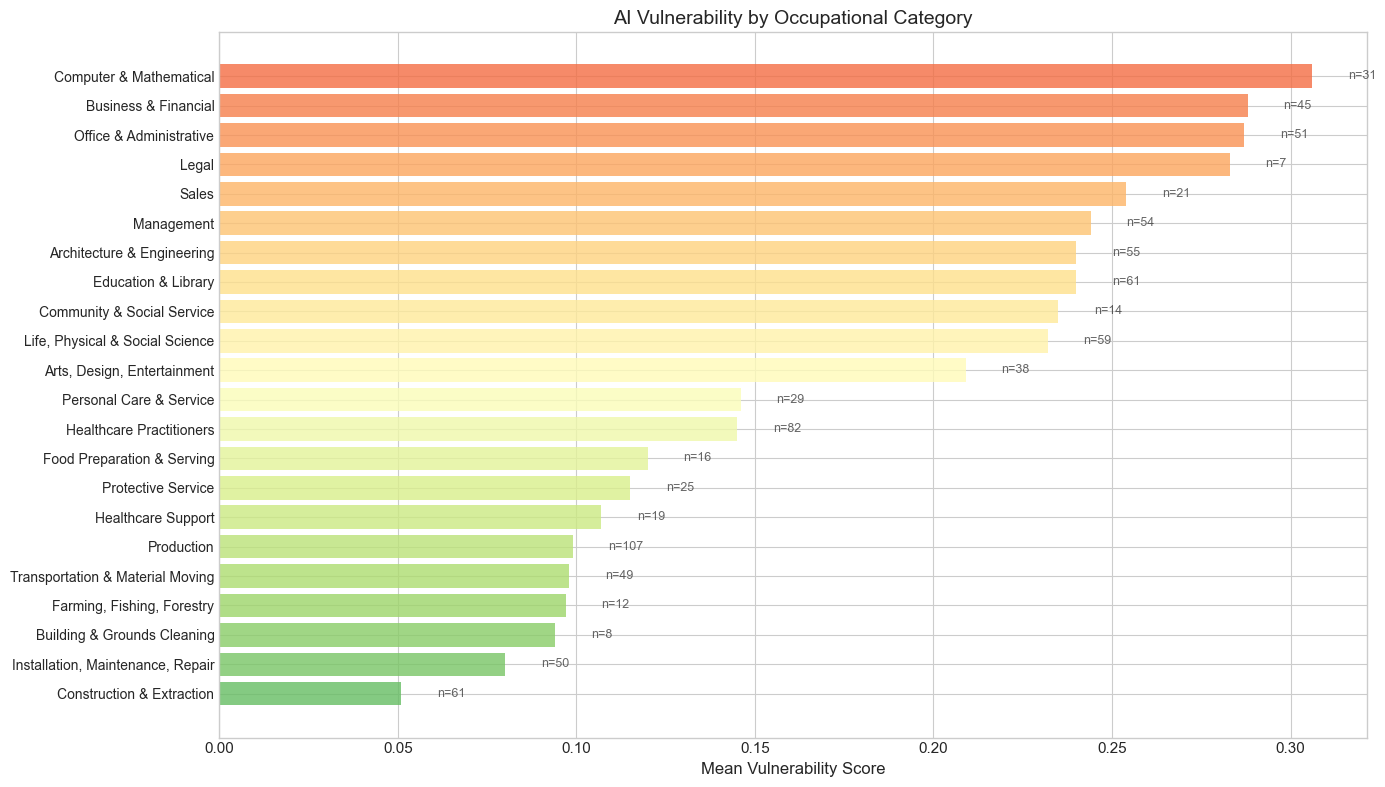

In [ ]:
# Visualize by major group
fig, ax = plt.subplots(figsize=(14, 8))

# Sort by vulnerability
major_group_stats_plot = major_group_stats.sort_values('vulnerability', ascending=True)

y_pos = range(len(major_group_stats_plot))
colors_bar = plt.cm.RdYlGn_r(np.linspace(0.2, 0.8, len(major_group_stats_plot)))

bars = ax.barh(y_pos, major_group_stats_plot['vulnerability'], color=colors_bar, alpha=0.8)
ax.set_yticks(y_pos)
ax.set_yticklabels(major_group_stats_plot.index, fontsize=10)
ax.set_xlabel('Mean Vulnerability Score', fontsize=12)
ax.set_title('AI Vulnerability by Occupational Category', fontsize=14)

# Add count labels
for i, (idx, row) in enumerate(major_group_stats_plot.iterrows()):
    ax.text(row['vulnerability'] + 0.01, i, f"n={int(row['n_occupations'])}", 
            va='center', fontsize=9, alpha=0.7)

plt.tight_layout()
plt.savefig('SOC_codes/vulnerability_by_category.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# Routine vs Non-routine analysis
# Classify based on task exposure patterns

# High pct_level_2 = routine cognitive (automatable)
# High pct_level_1 = non-routine cognitive (augmentable)
# High pct_level_0 = manual/physical

def classify_work_type(row):
    if row['pct_level_2'] > 40:
        return 'Routine Cognitive'
    elif row['pct_level_1'] > 50:
        return 'Non-routine Cognitive'
    elif row['pct_level_0'] > 50:
        if row['humanness_avg'] > 0.5:
            return 'Non-routine Manual (Interactive)'
        else:
            return 'Routine Manual'
    else:
        return 'Mixed'

merged['work_type'] = merged.apply(classify_work_type, axis=1)

work_type_stats = merged.groupby('work_type').agg({
    'vulnerability': ['mean', 'std'],
    'OnetSocCode': 'count'
}).round(3)
work_type_stats.columns = ['Mean Vulnerability', 'Std Dev', 'N Occupations']

print("\nAutor-Levy-Murnane Work Type Classification:")
print(work_type_stats.sort_values('Mean Vulnerability', ascending=False))


Autor-Levy-Murnane Work Type Classification:
                                  Mean Vulnerability  Std Dev  N Occupations
work_type                                                                   
Routine Cognitive                              0.421    0.052              2
Non-routine Cognitive                          0.247    0.060            482
Mixed                                          0.190    0.078             23
Routine Manual                                 0.101    0.041            199
Non-routine Manual (Interactive)               0.071    0.044            188


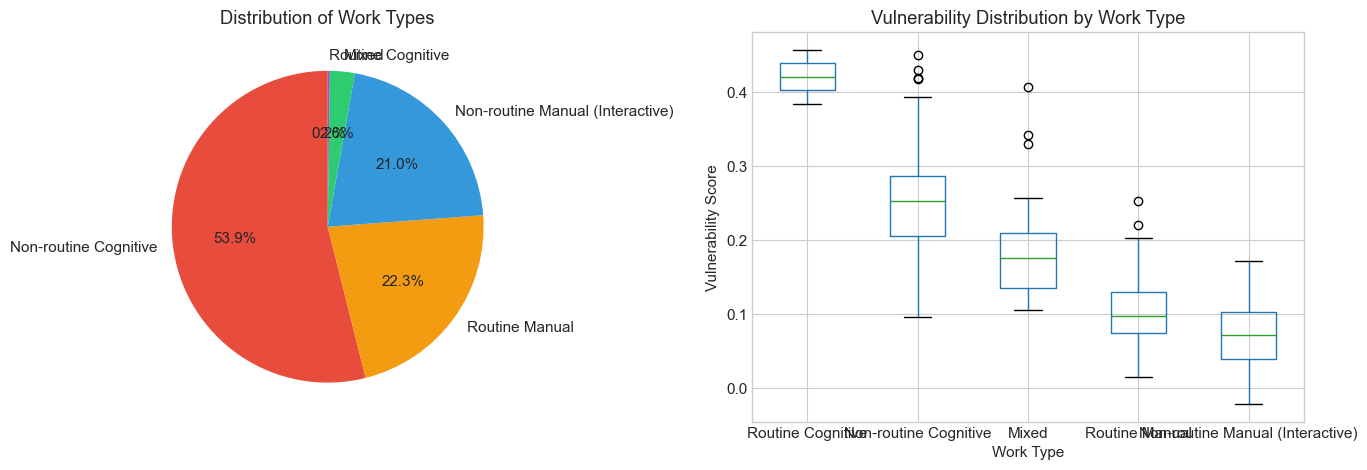

In [ ]:
# Work type visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Pie chart of work types
work_counts = merged['work_type'].value_counts()
colors_pie = ['#e74c3c', '#f39c12', '#3498db', '#2ecc71', '#9b59b6']
axes[0].pie(work_counts, labels=work_counts.index, autopct='%1.1f%%', colors=colors_pie, startangle=90)
axes[0].set_title('Distribution of Work Types')

# Box plot of vulnerability by work type
work_order = merged.groupby('work_type')['vulnerability'].mean().sort_values(ascending=False).index
merged['work_type'] = pd.Categorical(merged['work_type'], categories=work_order, ordered=True)

merged.boxplot(column='vulnerability', by='work_type', ax=axes[1])
axes[1].set_xlabel('Work Type')
axes[1].set_ylabel('Vulnerability Score')
axes[1].set_title('Vulnerability Distribution by Work Type')
plt.suptitle('')

plt.tight_layout()
plt.savefig('SOC_codes/work_type_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. 3D Visualization: The AI Exposure Landscape

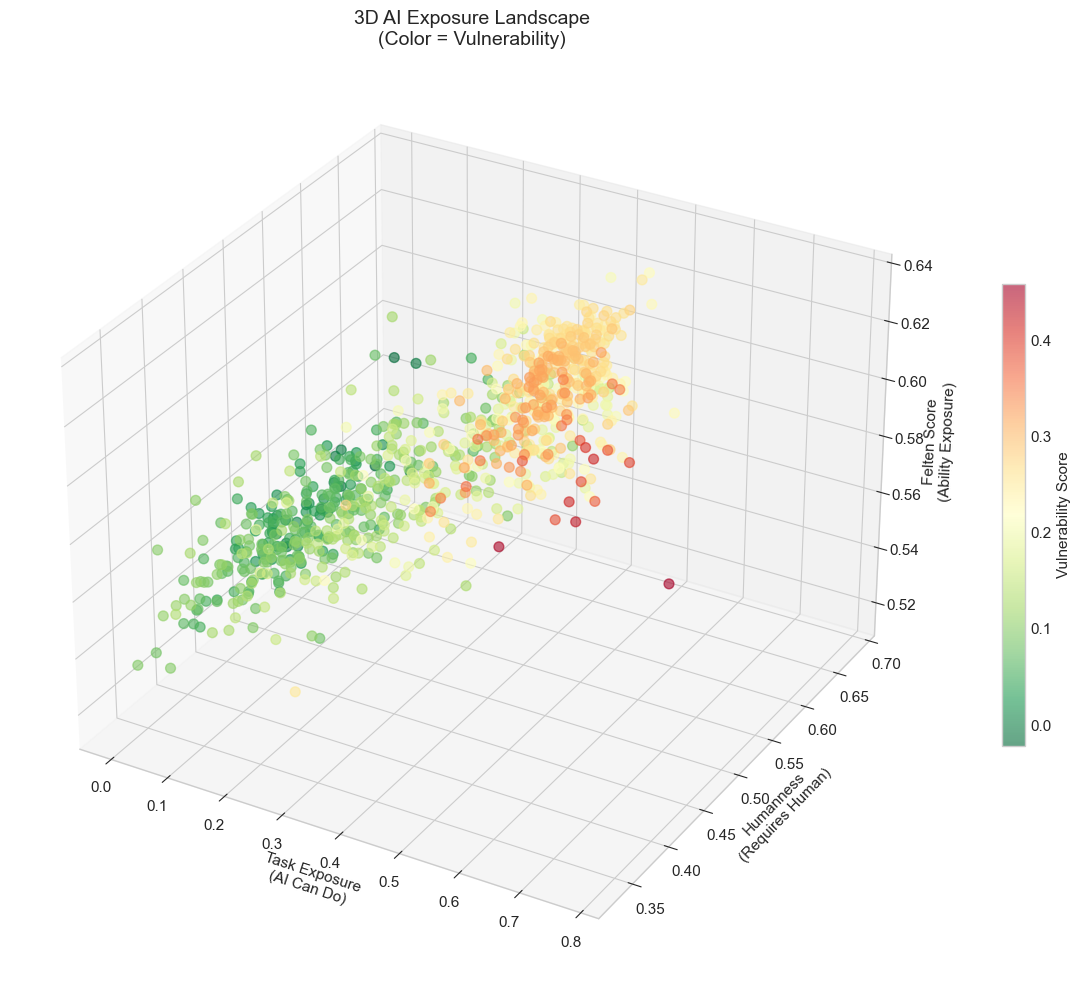

In [ ]:
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(14, 10))
ax = fig.add_subplot(111, projection='3d')

# Use vulnerability for color
colors_3d = plt.cm.RdYlGn_r(merged['vulnerability'] / merged['vulnerability'].max())

scatter = ax.scatter(
    merged['task_exposure_norm'],
    merged['humanness_avg'],
    merged['felten_score'],
    c=merged['vulnerability'],
    cmap='RdYlGn_r',
    s=50,
    alpha=0.6
)

ax.set_xlabel('Task Exposure\n(AI Can Do)', fontsize=11)
ax.set_ylabel('Humanness\n(Requires Human)', fontsize=11)
ax.set_zlabel('Felten Score\n(Ability Exposure)', fontsize=11)
ax.set_title('3D AI Exposure Landscape\n(Color = Vulnerability)', fontsize=14)

# Add colorbar
cbar = fig.colorbar(scatter, ax=ax, shrink=0.5, aspect=20)
cbar.set_label('Vulnerability Score', fontsize=11)

plt.tight_layout()
plt.savefig('SOC_codes/3d_exposure_landscape.png', dpi=150, bbox_inches='tight')
plt.show()

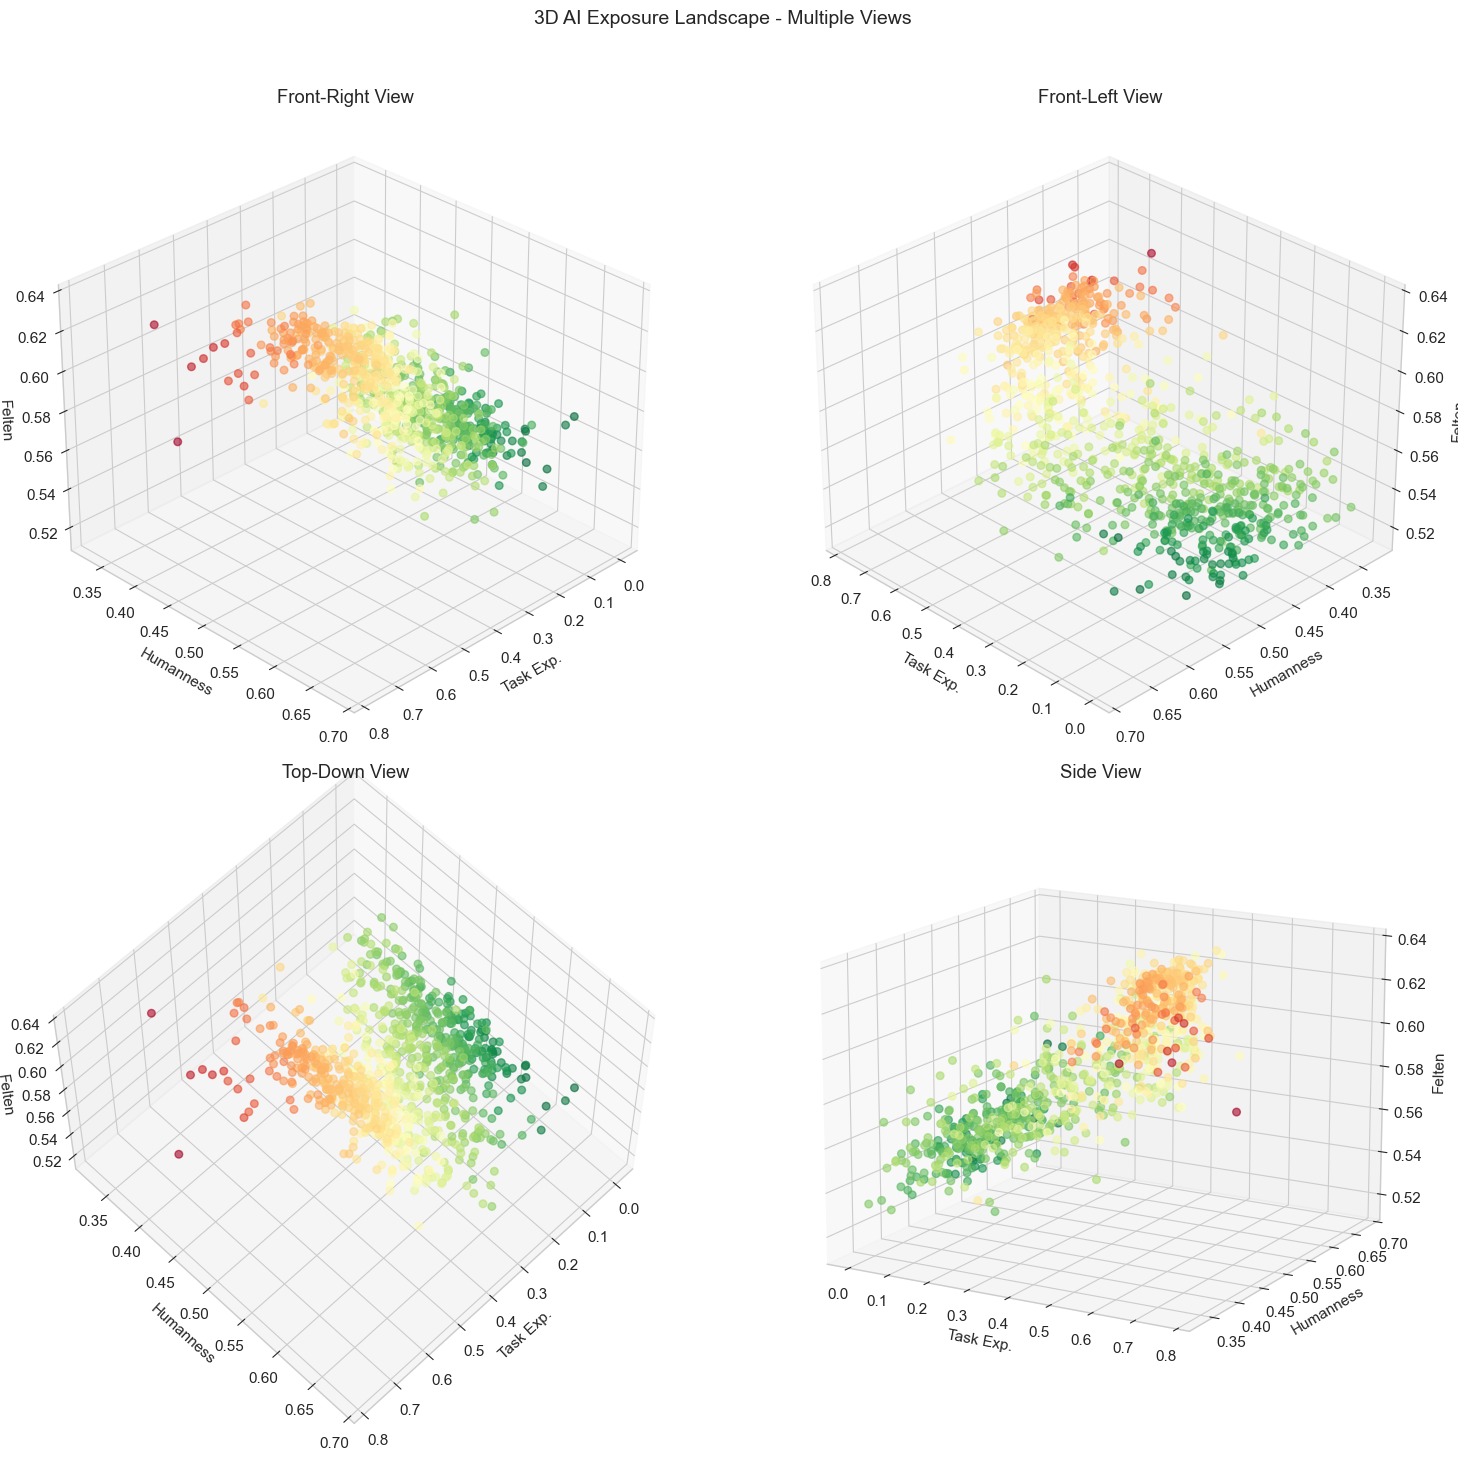

In [ ]:
# Interactive-style multiple angle views
fig, axes = plt.subplots(2, 2, figsize=(16, 14), subplot_kw={'projection': '3d'})

angles = [(30, 45), (30, 135), (60, 45), (15, -60)]
titles = ['Front-Right View', 'Front-Left View', 'Top-Down View', 'Side View']

for ax, (elev, azim), title in zip(axes.flat, angles, titles):
    scatter = ax.scatter(
        merged['task_exposure_norm'],
        merged['humanness_avg'],
        merged['felten_score'],
        c=merged['vulnerability'],
        cmap='RdYlGn_r',
        s=30,
        alpha=0.6
    )
    ax.view_init(elev=elev, azim=azim)
    ax.set_xlabel('Task Exp.')
    ax.set_ylabel('Humanness')
    ax.set_zlabel('Felten')
    ax.set_title(title)

plt.suptitle('3D AI Exposure Landscape - Multiple Views', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('SOC_codes/3d_multiple_views.png', dpi=150, bbox_inches='tight')
plt.show()

## 7.5 Divergent Cases: Where Scores Disagree

Some occupations show high vulnerability on one measure but low on another. These cases reveal the complementary nature of our scores and highlight nuanced automation dynamics.

In [ ]:
# Identify divergent cases
# Normalize all scores to same scale for comparison
from scipy.stats import zscore

merged['task_z'] = zscore(merged['task_exposure_norm'])
merged['human_z'] = zscore(merged['humanness_avg'])
merged['felten_z'] = zscore(merged['felten_score'])

# Case 1: High Task Exposure but High Humanness (AI can do it, but humans still needed)
high_task_high_human = merged[
    (merged['task_exposure_norm'] > merged['task_exposure_norm'].quantile(0.75)) &
    (merged['humanness_avg'] > merged['humanness_avg'].quantile(0.75))
].sort_values('task_exposure_norm', ascending=False)

print("=" * 80)
print("DIVERGENT CASE 1: High Task Exposure + High Humanness")
print("(AI CAN do these tasks, but human presence/judgment still essential)")
print("=" * 80)
print(f"Found {len(high_task_high_human)} occupations\n")
display_cols = ['Title', 'task_exposure_norm', 'humanness_avg', 'felten_score']
print(high_task_high_human[display_cols].head(10).to_string(index=False))

DIVERGENT CASE 1: High Task Exposure + High Humanness
(AI CAN do these tasks, but human presence/judgment still essential)
Found 56 occupations

                                    Title  task_exposure_norm  humanness_avg  felten_score
                       Freight Forwarders            0.548387       0.573199      0.602159
          Wind Energy Operations Managers            0.527778       0.658602      0.581749
             Health Education Specialists            0.523810       0.599472      0.596706
  Information Technology Project Managers            0.520000       0.597013      0.629985
                      Purchasing Managers            0.519231       0.572682      0.628562
                 Human Resources Managers            0.500000       0.605476      0.626106
                      Management Analysts            0.500000       0.587166      0.626995
              Clinical Neuropsychologists            0.500000       0.579351      0.616631
  Education Administrators, Postseco

In [ ]:
# Case 2: Low Task Exposure but High Felten (abilities are exposed, but tasks aren't automatable)
low_task_high_felten = merged[
    (merged['task_exposure_norm'] < merged['task_exposure_norm'].quantile(0.25)) &
    (merged['felten_score'] > merged['felten_score'].quantile(0.75))
].sort_values('felten_score', ascending=False)

print("\n" + "=" * 80)
print("DIVERGENT CASE 2: Low Task Exposure + High Felten Score")
print("(Cognitive abilities ARE exposed to AI, but specific tasks aren't automatable)")
print("=" * 80)
print(f"Found {len(low_task_high_felten)} occupations\n")
print(low_task_high_felten[display_cols].head(10).to_string(index=False))


DIVERGENT CASE 2: Low Task Exposure + High Felten Score
(Cognitive abilities ARE exposed to AI, but specific tasks aren't automatable)
Found 0 occupations

Empty DataFrame
Columns: [Title, task_exposure_norm, humanness_avg, felten_score]
Index: []


In [ ]:
# Case 3: High Task Exposure but Low Felten (tasks automatable, but not due to cognitive abilities)
high_task_low_felten = merged[
    (merged['task_exposure_norm'] > merged['task_exposure_norm'].quantile(0.75)) &
    (merged['felten_score'] < merged['felten_score'].quantile(0.25))
].sort_values('task_exposure_norm', ascending=False)

print("\n" + "=" * 80)
print("DIVERGENT CASE 3: High Task Exposure + Low Felten Score")
print("(Tasks ARE automatable, but through non-cognitive/routine channels)")
print("=" * 80)
print(f"Found {len(high_task_low_felten)} occupations\n")
print(high_task_low_felten[display_cols].head(10).to_string(index=False))


DIVERGENT CASE 3: High Task Exposure + Low Felten Score
(Tasks ARE automatable, but through non-cognitive/routine channels)
Found 0 occupations

Empty DataFrame
Columns: [Title, task_exposure_norm, humanness_avg, felten_score]
Index: []


In [ ]:
# Case 4: Low Humanness but Low Task Exposure (not human-centric, but also not AI-automatable)
low_human_low_task = merged[
    (merged['humanness_avg'] < merged['humanness_avg'].quantile(0.25)) &
    (merged['task_exposure_norm'] < merged['task_exposure_norm'].quantile(0.25))
].sort_values('humanness_avg', ascending=True)

print("\n" + "=" * 80)
print("DIVERGENT CASE 4: Low Humanness + Low Task Exposure")
print("(Physical/manual work - not human-centric, but also not AI-automatable)")
print("=" * 80)
print(f"Found {len(low_human_low_task)} occupations\n")
print(low_human_low_task[display_cols].head(10).to_string(index=False))


DIVERGENT CASE 4: Low Humanness + Low Task Exposure
(Physical/manual work - not human-centric, but also not AI-automatable)
Found 103 occupations

                                            Title  task_exposure_norm  humanness_avg  felten_score
                                      Dishwashers            0.000000       0.340636      0.532743
                         Sewing Machine Operators            0.060606       0.347941      0.552801
                         Food Preparation Workers            0.025000       0.356722      0.548012
Pressers, Textile, Garment, and Related Materials            0.027778       0.361268      0.528490
                       Cutters and Trimmers, Hand            0.040000       0.362644      0.551187
                    Slaughterers and Meat Packers            0.000000       0.363359      0.531757
                                     Sewers, Hand            0.000000       0.369602      0.566699
                    Motion Picture Projectionists           

## 7.6 Labeled Visualizations: Occupations Across the Score Space

These plots show a sample of occupations from different regions of the exposure landscape, with labels for interpretability.

In [ ]:
def sample_from_regions(df, x_col, y_col, n_per_region=3, seed=42):
    """
    Sample occupations from different regions of the 2D score space.
    Divides space into 9 regions (3x3 grid) and samples from each.
    """
    np.random.seed(seed)
    
    x_terciles = df[x_col].quantile([0.33, 0.67]).values
    y_terciles = df[y_col].quantile([0.33, 0.67]).values
    
    samples = []
    
    for x_low, x_high in [(df[x_col].min(), x_terciles[0]), 
                          (x_terciles[0], x_terciles[1]), 
                          (x_terciles[1], df[x_col].max())]:
        for y_low, y_high in [(df[y_col].min(), y_terciles[0]), 
                              (y_terciles[0], y_terciles[1]), 
                              (y_terciles[1], df[y_col].max())]:
            region = df[
                (df[x_col] >= x_low) & (df[x_col] <= x_high) &
                (df[y_col] >= y_low) & (df[y_col] <= y_high)
            ]
            if len(region) > 0:
                n_sample = min(n_per_region, len(region))
                samples.append(region.sample(n=n_sample))
    
    return pd.concat(samples).drop_duplicates()

print(f"Sampling function ready. Will sample ~{3*9} occupations from 9 regions.")

Sampling function ready. Will sample ~27 occupations from 9 regions.


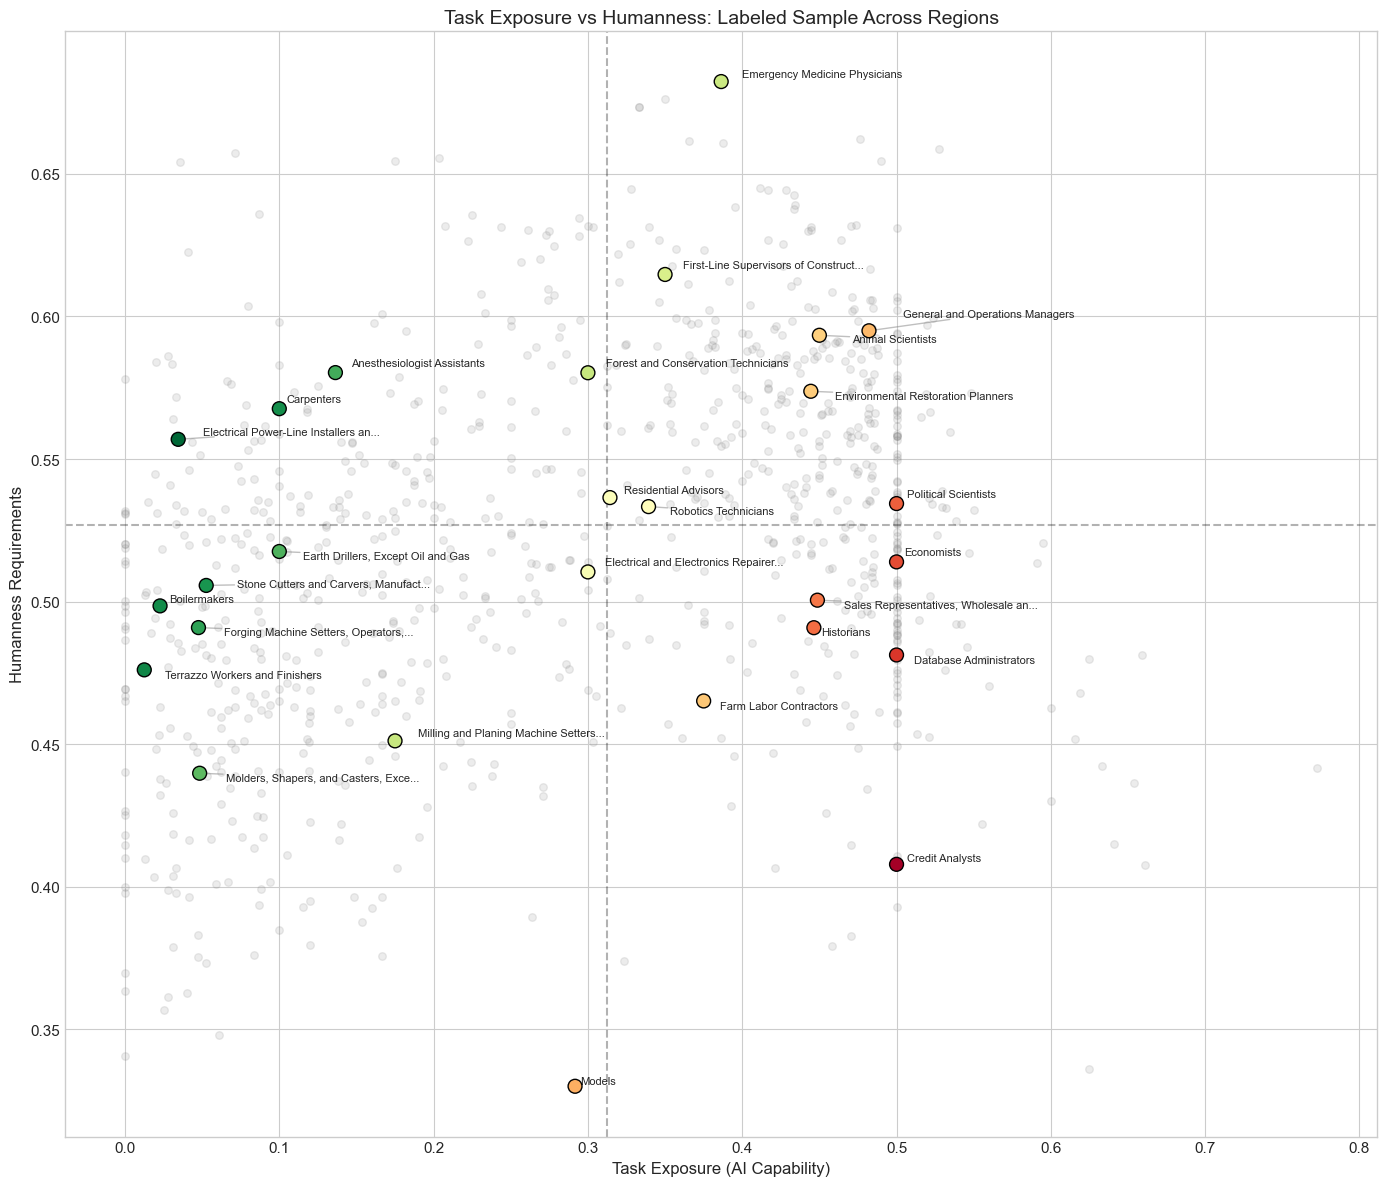

In [ ]:
# Plot 1: Task Exposure vs Humanness with labels
fig, ax = plt.subplots(figsize=(14, 12))

# Plot all points faintly
ax.scatter(merged['task_exposure_norm'], merged['humanness_avg'], 
           alpha=0.15, c='gray', s=30)

# Sample and highlight labeled points
labeled_sample = sample_from_regions(merged, 'task_exposure_norm', 'humanness_avg', n_per_region=3)

ax.scatter(labeled_sample['task_exposure_norm'], labeled_sample['humanness_avg'],
           c=labeled_sample['vulnerability'], cmap='RdYlGn_r', 
           s=100, edgecolors='black', linewidth=1, zorder=5)

# Add labels with smart positioning
from adjustText import adjust_text
texts = []
for _, row in labeled_sample.iterrows():
    # Truncate long titles
    title = row['Title'][:35] + '...' if len(row['Title']) > 35 else row['Title']
    texts.append(ax.text(row['task_exposure_norm'], row['humanness_avg'], title, fontsize=8))

try:
    adjust_text(texts, arrowprops=dict(arrowstyle='-', color='gray', alpha=0.5))
except:
    pass  # If adjustText not available, labels will overlap but still show

# Quadrant lines
ax.axvline(merged['task_exposure_norm'].median(), color='black', linestyle='--', alpha=0.3)
ax.axhline(merged['humanness_avg'].median(), color='black', linestyle='--', alpha=0.3)

ax.set_xlabel('Task Exposure (AI Capability)', fontsize=12)
ax.set_ylabel('Humanness Requirements', fontsize=12)
ax.set_title('Task Exposure vs Humanness: Labeled Sample Across Regions', fontsize=14)

plt.tight_layout()
plt.savefig('SOC_codes/labeled_task_vs_humanness.png', dpi=150, bbox_inches='tight')
plt.show()

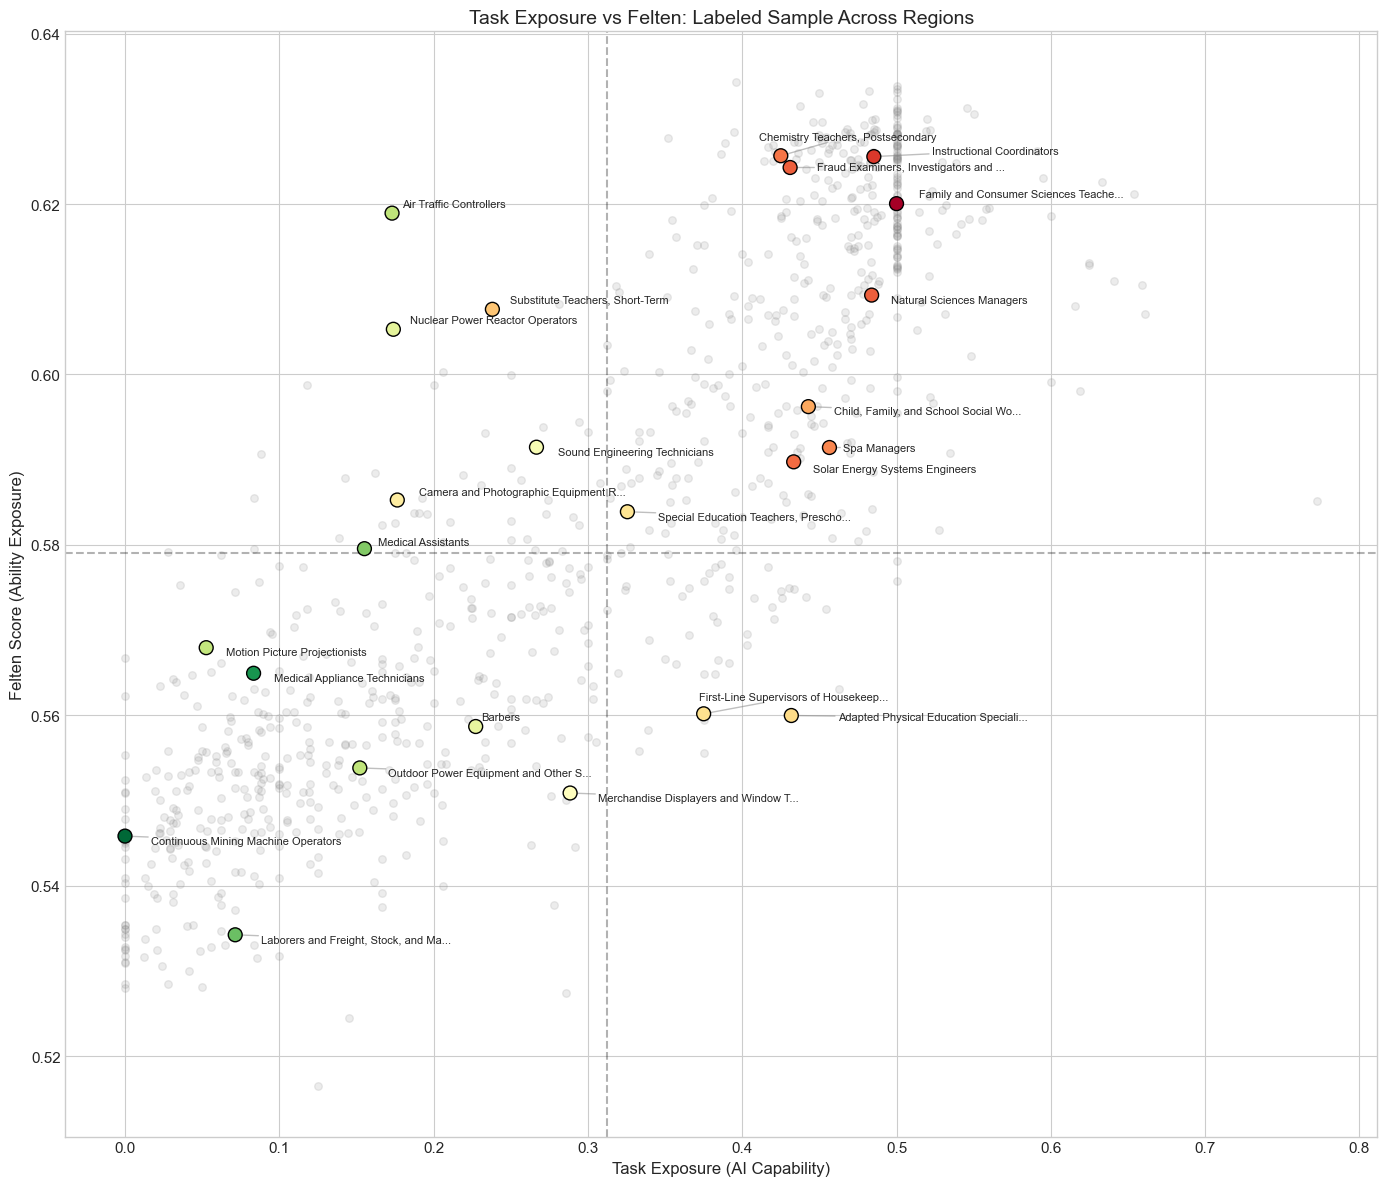

In [ ]:
# Plot 2: Task Exposure vs Felten with labels
fig, ax = plt.subplots(figsize=(14, 12))

ax.scatter(merged['task_exposure_norm'], merged['felten_score'], 
           alpha=0.15, c='gray', s=30)

labeled_sample2 = sample_from_regions(merged, 'task_exposure_norm', 'felten_score', n_per_region=3)

ax.scatter(labeled_sample2['task_exposure_norm'], labeled_sample2['felten_score'],
           c=labeled_sample2['vulnerability'], cmap='RdYlGn_r', 
           s=100, edgecolors='black', linewidth=1, zorder=5)

texts = []
for _, row in labeled_sample2.iterrows():
    title = row['Title'][:35] + '...' if len(row['Title']) > 35 else row['Title']
    texts.append(ax.text(row['task_exposure_norm'], row['felten_score'], title, fontsize=8))

try:
    adjust_text(texts, arrowprops=dict(arrowstyle='-', color='gray', alpha=0.5))
except:
    pass

ax.axvline(merged['task_exposure_norm'].median(), color='black', linestyle='--', alpha=0.3)
ax.axhline(merged['felten_score'].median(), color='black', linestyle='--', alpha=0.3)

ax.set_xlabel('Task Exposure (AI Capability)', fontsize=12)
ax.set_ylabel('Felten Score (Ability Exposure)', fontsize=12)
ax.set_title('Task Exposure vs Felten: Labeled Sample Across Regions', fontsize=14)

plt.tight_layout()
plt.savefig('SOC_codes/labeled_task_vs_felten.png', dpi=150, bbox_inches='tight')
plt.show()

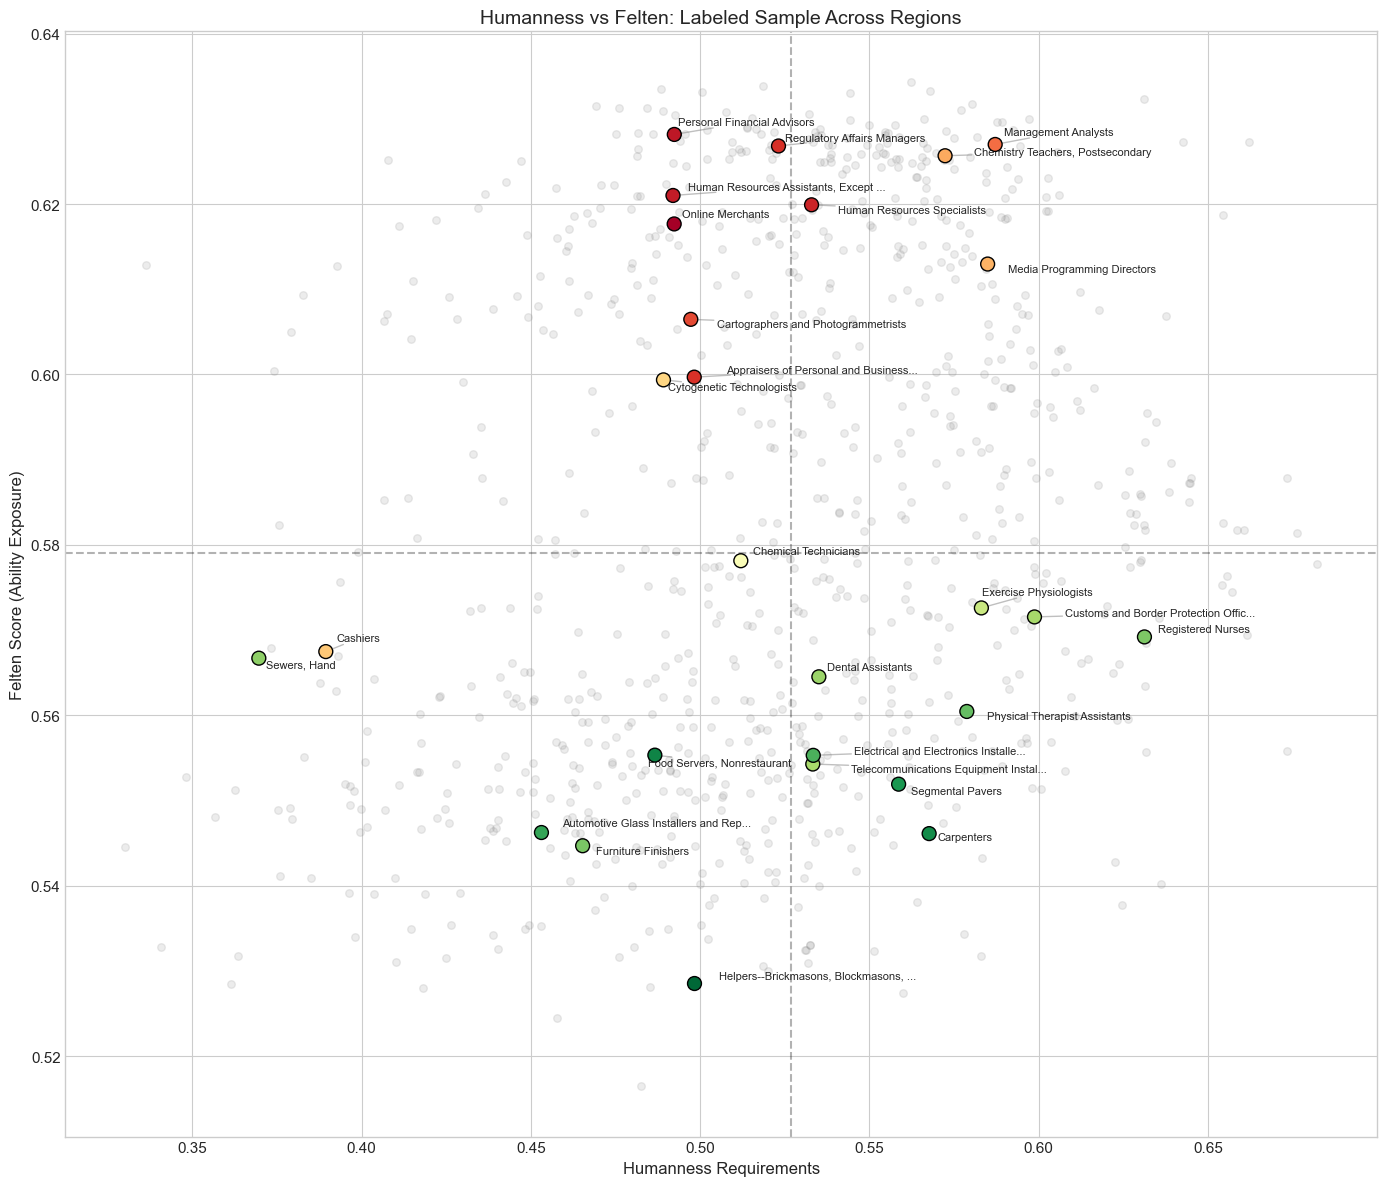

In [ ]:
# Plot 3: Humanness vs Felten with labels
fig, ax = plt.subplots(figsize=(14, 12))

ax.scatter(merged['humanness_avg'], merged['felten_score'], 
           alpha=0.15, c='gray', s=30)

labeled_sample3 = sample_from_regions(merged, 'humanness_avg', 'felten_score', n_per_region=3)

ax.scatter(labeled_sample3['humanness_avg'], labeled_sample3['felten_score'],
           c=labeled_sample3['vulnerability'], cmap='RdYlGn_r', 
           s=100, edgecolors='black', linewidth=1, zorder=5)

texts = []
for _, row in labeled_sample3.iterrows():
    title = row['Title'][:35] + '...' if len(row['Title']) > 35 else row['Title']
    texts.append(ax.text(row['humanness_avg'], row['felten_score'], title, fontsize=8))

try:
    adjust_text(texts, arrowprops=dict(arrowstyle='-', color='gray', alpha=0.5))
except:
    pass

ax.axvline(merged['humanness_avg'].median(), color='black', linestyle='--', alpha=0.3)
ax.axhline(merged['felten_score'].median(), color='black', linestyle='--', alpha=0.3)

ax.set_xlabel('Humanness Requirements', fontsize=12)
ax.set_ylabel('Felten Score (Ability Exposure)', fontsize=12)
ax.set_title('Humanness vs Felten: Labeled Sample Across Regions', fontsize=14)

plt.tight_layout()
plt.savefig('SOC_codes/labeled_humanness_vs_felten.png', dpi=150, bbox_inches='tight')
plt.show()

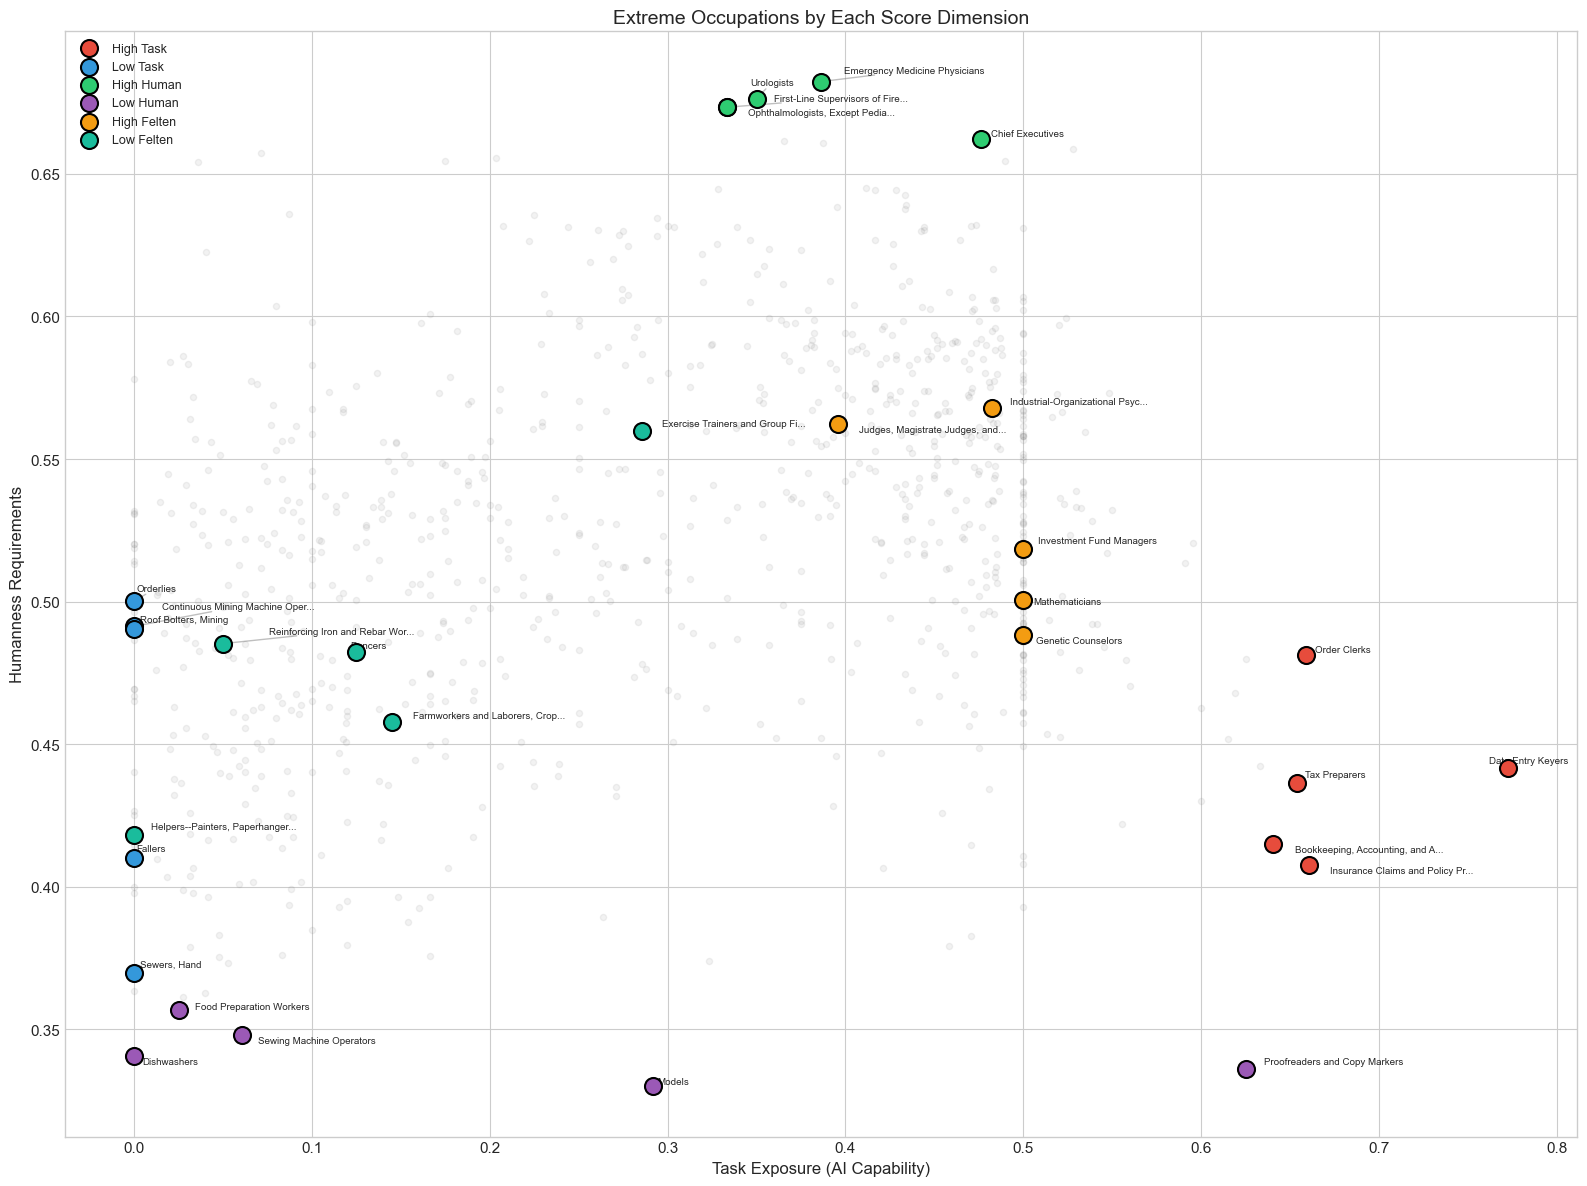

In [ ]:
# Plot 4: Combined view - Sample extreme occupations from each dimension
fig, ax = plt.subplots(figsize=(16, 12))

# Get extremes from each dimension
top_task = merged.nlargest(5, 'task_exposure_norm')
bottom_task = merged.nsmallest(5, 'task_exposure_norm')
top_human = merged.nlargest(5, 'humanness_avg')
bottom_human = merged.nsmallest(5, 'humanness_avg')
top_felten = merged.nlargest(5, 'felten_score')
bottom_felten = merged.nsmallest(5, 'felten_score')

extremes = pd.concat([top_task, bottom_task, top_human, bottom_human, 
                      top_felten, bottom_felten]).drop_duplicates()

# Background scatter
ax.scatter(merged['task_exposure_norm'], merged['humanness_avg'], 
           alpha=0.1, c='gray', s=20)

# Color-code by which extreme they represent
colors_extreme = {
    'High Task': '#e74c3c',
    'Low Task': '#3498db', 
    'High Human': '#2ecc71',
    'Low Human': '#9b59b6',
    'High Felten': '#f39c12',
    'Low Felten': '#1abc9c'
}

def get_extreme_type(soc):
    if soc in top_task['OnetSocCode'].values: return 'High Task'
    if soc in bottom_task['OnetSocCode'].values: return 'Low Task'
    if soc in top_human['OnetSocCode'].values: return 'High Human'
    if soc in bottom_human['OnetSocCode'].values: return 'Low Human'
    if soc in top_felten['OnetSocCode'].values: return 'High Felten'
    if soc in bottom_felten['OnetSocCode'].values: return 'Low Felten'
    return 'Other'

extremes['extreme_type'] = extremes['OnetSocCode'].apply(get_extreme_type)

for ext_type, color in colors_extreme.items():
    subset = extremes[extremes['extreme_type'] == ext_type]
    ax.scatter(subset['task_exposure_norm'], subset['humanness_avg'],
               c=color, s=150, edgecolors='black', linewidth=1.5, 
               label=ext_type, zorder=5)

# Add labels
texts = []
for _, row in extremes.iterrows():
    title = row['Title'][:30] + '...' if len(row['Title']) > 30 else row['Title']
    texts.append(ax.text(row['task_exposure_norm'], row['humanness_avg'], title, fontsize=7))

try:
    adjust_text(texts, arrowprops=dict(arrowstyle='-', color='gray', alpha=0.5))
except:
    pass

ax.set_xlabel('Task Exposure (AI Capability)', fontsize=12)
ax.set_ylabel('Humanness Requirements', fontsize=12)
ax.set_title('Extreme Occupations by Each Score Dimension', fontsize=14)
ax.legend(loc='upper left', fontsize=9)

plt.tight_layout()
plt.savefig('SOC_codes/labeled_extremes_all_dimensions.png', dpi=150, bbox_inches='tight')
plt.show()

### Interpretation of Divergent Cases

**High Task + High Humanness**: These are *augmentation candidates* - AI can assist but human presence remains critical. Examples include managers, counselors, and healthcare roles where AI can handle documentation but human judgment/relationship is key.

**Low Task + High Felten**: These occupations have cognitive abilities that AI *could* theoretically affect, but the specific tasks aren't automatable - often due to physical, regulatory, or contextual barriers.

**High Task + Low Felten**: Routine clerical/processing work that's automatable not through cognitive ability replacement but through process automation.

**Low Human + Low Task**: Physical/manual work that neither requires human interaction nor is automatable by LLMs - protected by physicality rather than humanness.

## 8. Summary and Key Findings

In [ ]:
print("=" * 80)
print("SUMMARY STATISTICS")
print("=" * 80)

print(f"\nTotal occupations analyzed: {len(merged)}")
print(f"\nScore Ranges:")
print(f"  Task Exposure: {merged['task_exposure_norm'].min():.2f} - {merged['task_exposure_norm'].max():.2f}")
print(f"  Humanness: {merged['humanness_avg'].min():.2f} - {merged['humanness_avg'].max():.2f}")
print(f"  Felten Score: {merged['felten_score'].min():.2f} - {merged['felten_score'].max():.2f}")

print(f"\nVulnerability Distribution:")
print(f"  High vulnerability (top 25%): {len(merged[merged['vulnerability'] >= merged['vulnerability'].quantile(0.75)])} occupations")
print(f"  Medium vulnerability (25-75%): {len(merged[(merged['vulnerability'] >= merged['vulnerability'].quantile(0.25)) & (merged['vulnerability'] < merged['vulnerability'].quantile(0.75))])} occupations")
print(f"  Low vulnerability (bottom 25%): {len(merged[merged['vulnerability'] < merged['vulnerability'].quantile(0.25)])} occupations")

print(f"\nQuadrant Distribution:")
for q, count in merged['quadrant'].value_counts().items():
    print(f"  {q.split(chr(10))[0]}: {count} ({100*count/len(merged):.1f}%)")

SUMMARY STATISTICS

Total occupations analyzed: 894

Score Ranges:
  Task Exposure: 0.00 - 0.77
  Humanness: 0.33 - 0.68
  Felten Score: 0.52 - 0.63

Vulnerability Distribution:
  High vulnerability (top 25%): 224 occupations
  Medium vulnerability (25-75%): 446 occupations
  Low vulnerability (bottom 25%): 224 occupations

Quadrant Distribution:
  High Exposure, High Humanness: 292 (32.7%)
  Low Exposure, Low Humanness: 290 (32.4%)
  High Exposure, Low Humanness: 157 (17.6%)
  Low Exposure, High Humanness: 155 (17.3%)


In [ ]:
# Save the merged dataset
merged.to_csv('SOC_codes/merged_all_scores.csv', index=False)
print(f"\nSaved merged dataset to SOC_codes/merged_all_scores.csv")

# Save summary by major group
major_group_stats.to_csv('SOC_codes/vulnerability_by_major_group.csv')
print(f"Saved major group summary to SOC_codes/vulnerability_by_major_group.csv")


Saved merged dataset to SOC_codes/merged_all_scores.csv
Saved major group summary to SOC_codes/vulnerability_by_major_group.csv


### Key Insights

1. **Score Complementarity**: The three measures capture different dimensions of AI impact - task capability, human requirements, and cognitive ability exposure.

2. **Automation Risk Zone**: Occupations with high task exposure + low humanness are at greatest risk (e.g., data entry, clerical work, routine processing).

3. **Human Stronghold**: Occupations requiring physical presence, emotional intelligence, or creative judgment remain protected (e.g., healthcare, trades, emergency services).

4. **Augmentation Zone**: Many knowledge-work occupations show high AI capability but also high humanness - these are candidates for human-AI collaboration rather than replacement.

5. **Occupational Hierarchy**: Administrative/clerical roles show highest vulnerability, while protective services, healthcare, and skilled trades show lowest.